Loaded Wave 5 (2013) successfully: 2626 rows


C:\Users\kitti\AppData\Local\Temp\ipykernel_36348\1617074849.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_13, x='shocks_Group', palette='Set3')


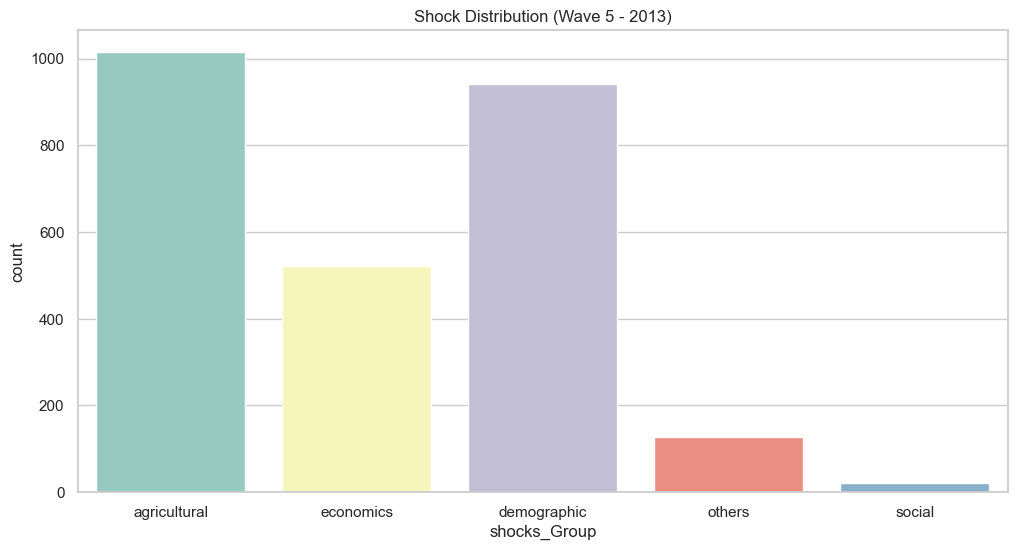

Success: shocks_2013_cleaned_final.csv is ready for Panel integration.


In [1]:
# ==============================================================================
# STEP 1: SETUP & LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==============================================================================
# STEP 2: DATA LOADING (Wave 5 Specific)
# ==============================================================================
# ใช้ convert_categoricals=False เพื่อเลี่ยงปัญหา Duplicate Labels ในระดับหมู่บ้าน
file_2013 = 'wave-5-2013-shocksclean.dta'
df_13 = pd.read_stata(file_2013, convert_categoricals=False)

print(f"Loaded Wave 5 (2013) successfully: {len(df_13)} rows")

# ==============================================================================
# STEP 3: DATA CLEANING (Standard Research Logic)
# ==============================================================================
def clean_wave5(df):
    # จัดการ Missing Values (-9, -99)
    df = df.replace([-9, -99, -9.0, -99.0], np.nan)
    
    # จัดการคอลัมน์การเงิน (Loss Amount: _x31005a)
    if '_x31005a' in df.columns:
        df['_x31005a'] = df['_x31005a'].astype(str).str.replace('none', '0', case=False).str.strip()
        df['_x31005a'] = pd.to_numeric(df['_x31005a'], errors='coerce').fillna(0)
    
    return df

df_13 = clean_wave5(df_13)

# ==============================================================================
# STEP 4: COPING STRATEGY HARMONIZATION (เจาะลึก _x31008 - _x31010)
# ==============================================================================
# Mapping รหัสรับมือปี 2013 ให้เป็นหมวดหมู่สากลของโปรเจกต์
coping_map_13 = {
    11: 'sold_assets', 12: 'sold_assets', 13: 'sold_assets', 14: 'sold_assets',
    15: 'used_savings', 16: 'used_insurance',
    17: 'borrowed_informal', 18: 'borrowed_informal',
    21: 'borrowed_formal', 22: 'borrowed_formal', 23: 'borrowed_formal',
    28: 'gov_help', 29: 'gov_help', 30: 'relatives_help'
}

coping_cols = ['sold_assets', 'used_savings', 'used_insurance', 'borrowed_informal', 'borrowed_formal', 'gov_help']
for c in coping_cols:
    df_13[f'coping_{c}'] = 0

# แตกข้อมูลจาก 3 ลำดับ เป็น Binary Indicators
for col in ['_x31008', '_x31009', '_x31010']:
    if col in df_13.columns:
        for code, name in coping_map_13.items():
            df_13.loc[df_13[col] == code, f'coping_{name}'] = 1

# ==============================================================================
# STEP 5: SHOCK GROUPING (Matching consistent categories)
# ==============================================================================
shock_map_13 = {
    10: 'agricultural', 11: 'agricultural', 63: 'agricultural', 55: 'agricultural',
    1: 'demographic', 2: 'demographic', 3: 'demographic', 24: 'demographic',
    5: 'economics', 6: 'economics', 18: 'economics', 21: 'economics', 22: 'economics', 62: 'economics',
    8: 'social', 70: 'social', 77: 'economics'
}

df_13['shocks_Group'] = df_13['_x31002'].map(shock_map_13).fillna('others')
df_13['survey_year'] = 2013

# ==============================================================================
# STEP 6: EXPORT
# ==============================================================================
output_file = 'shocks_2013_cleaned_final.csv'
df_13.to_csv(output_file, index=False)

# Visualization เพื่อตรวจสอบการกระจายตัว
sns.countplot(data=df_13, x='shocks_Group', palette='Set3')
plt.title('Shock Distribution (Wave 5 - 2013)')
plt.show()

print(f"Success: {output_file} is ready for Panel integration.")